In [1]:
# If needed
# !pip install pandas numpy scikit-learn nltk matplotlib seaborn

import pandas as pd
import numpy as np

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [3]:
df = pd.read_csv("Sampled Olive Oil Brands.csv")

df.head()

,Brand,Country,Type,Acidity (%),Price (£),Rating (/10)
0,Filippo Berio,Italy,Extra Virgin,0.4,7.5,7.8
1,Bertolli,Italy,Extra Virgin,0.5,6.8,7.2
2,Cobram Estate,Australia,Extra Virgin,0.3,9.2,8.5
3,Kirkland Signature,Spain,Extra Virgin,0.2,8.0,8.7
4,Lucini,Italy,Premium Select,0.3,10.5,9.0


In [5]:


df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         10 non-null     str    
 1   Country       10 non-null     str    
 2   Type          10 non-null     str    
 3   Acidity (%)   10 non-null     float64
 4   Price (£)     10 non-null     float64
 5   Rating (/10)  10 non-null     float64
dtypes: float64(3), str(3)
memory usage: 914.0 bytes


In [7]:
import string

def preprocess_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]
    
    return " ".join(words)

In [10]:
print(df.columns)
print(df.head())

Index(['Brand', 'Country', 'Type', 'Acidity (%)', 'Price (£)', 'Rating (/10)'], dtype='str')
                Brand    Country            Type  Acidity (%)  Price (£)  \
0       Filippo Berio      Italy    Extra Virgin          0.4        7.5   
1            Bertolli      Italy    Extra Virgin          0.5        6.8   
2       Cobram Estate  Australia    Extra Virgin          0.3        9.2   
3  Kirkland Signature      Spain    Extra Virgin          0.2        8.0   
4              Lucini      Italy  Premium Select          0.3       10.5   

   Rating (/10)  
0           7.8  
1           7.2  
2           8.5  
3           8.7  
4           9.0  


In [13]:
print(df.columns)

Index(['Brand', 'Country', 'Type', 'Acidity (%)', 'Price (£)', 'Rating (/10)'], dtype='str')


In [14]:
df.columns = df.columns.str.strip().str.lower()

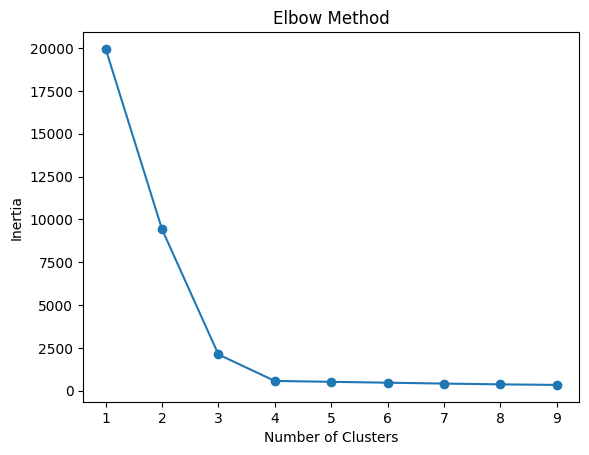

In [16]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Example data
X, _ = make_blobs(n_samples=300, centers=4, random_state=42)

inertia = []
K_range = range(1, 10)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X)
    inertia.append(model.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [18]:
print(X.shape)
print(df.shape)

(300, 2)
(10, 6)


In [21]:
print(df.columns)

Index(['brand', 'country', 'type', 'acidity (%)', 'price (£)', 'rating (/10)'], dtype='str')


In [26]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import KMeans

# Step 1: Your data
documents = [
    "I love machine learning",
    "Clustering is fun",
    "KMeans groups similar data",
    "Text data needs vectorization"
]

# Step 2: Vectorize
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(documents)

# Step 3: Choose number of clusters
k = 2

# Step 4: Fit KMeans
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X)

# Step 5: Extract terms
terms = vectorizer.get_feature_names_out()

# Step 6: Top words per cluster
for i in range(k):
    print(f"\nCluster {i} Top Words:")
    
    center = kmeans.cluster_centers_[i]
    top_indices = center.argsort()[-5:][::-1]
    
    top_words = [terms[idx] for idx in top_indices]
    print(top_words)


Cluster 0 Top Words:
['machine', 'love', 'learning', 'is', 'fun']

Cluster 1 Top Words:
['data', 'vectorization', 'text', 'similar', 'needs']
